# TriageGeist

**Predicting Emergency Severity Index (ESI) triage acuity levels 1–5** from structured clinical data collected at ED arrival — 5-class classification evaluated on Macro F1.

**Live Demo:** [triagegeist.onrender.com](https://triagegeist.onrender.com/)

## Clinical Problem Statement

### Background
Emergency departments (EDs) operate under constant time pressure. Triage nurses use the **Emergency Severity Index (ESI)** — a validated 5-tier protocol — to sort arriving patients by acuity within minutes of arrival. Level 1 (Resuscitation) demands immediate intervention; Level 5 (Non-Urgent) can wait. Getting this wrong is costly: **under-triage** (assigning too low an acuity) delays care for patients in danger; **over-triage** wastes scarce resuscitation resources.

Human triage is fast but imperfect. Under time pressure, inter-rater agreement on ESI assignment is typically 60–80% for borderline cases (Levels 2–4). A machine learning model trained on structured triage data — vital signs, chief complaint, GCS, arrival mode, comorbidities — could provide a real-time second opinion, flagging likely discrepancies before a patient is sent to the waiting room.

### Clinical Question
> *Can we predict a patient's ESI triage level from structured data available at the point of triage, with sufficient accuracy across all five acuity levels to support clinical decision-making?*

### Why Macro F1?
Class imbalance in ED triage is severe: Level 3 (Urgent) accounts for roughly 40% of visits, while Levels 1 and 5 are each under 10%. Optimizing for accuracy allows a model to ignore the rarest — and most clinically critical — classes. **Macro F1** weights all five ESI levels equally, ensuring that rare, high-stakes cases (L1 Resuscitation) receive the same penalty for misclassification as common presentations.

## Setup

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import torch
import importlib
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Force-reload src modules so edits take effect without a kernel restart
import src.utils, src.feature_engineering, src.models
importlib.reload(src.utils)
importlib.reload(src.feature_engineering)
importlib.reload(src.models)

from src.utils import (
    SEED, ACUITY_COLORS, ACUITY_LABELS, PLOTLY_LAYOUT,
    plot_confusion_matrix, plot_feature_importance, plot_f1_by_class, evaluate,
)

np.random.seed(SEED)
torch.manual_seed(SEED)

# ---- GPU status per framework ----------------------------------------------------------------------------------------------------
import lightgbm as lgb, xgboost as xgb

torch_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

try:
    _ds = lgb.Dataset(np.random.rand(20, 5), label=np.random.randint(0, 5, 20))
    lgb.train({'objective': 'multiclass', 'num_class': 5, 'device': 'gpu',
               'verbose': -1, 'num_leaves': 4}, _ds, num_boost_round=1)
    lgbm_device = 'gpu (OpenCL)'
except Exception:
    lgbm_device = 'cpu'

try:
    _dm = xgb.DMatrix(np.random.rand(20, 5), label=np.random.randint(0, 5, 20))
    xgb.train({'tree_method': 'hist', 'device': 'cuda',
               'objective': 'multi:softmax', 'num_class': 5}, _dm, num_boost_round=1)
    xgb_device = 'cuda'
except Exception:
    xgb_device = 'cpu'

print(f'PyTorch  : {torch_device}')
print(f'LightGBM : {lgbm_device}')
print(f'XGBoost  : {xgb_device}')

PyTorch  : cpu
LightGBM : gpu (OpenCL)
XGBoost  : cuda


## Data

In [11]:
train_raw = pd.read_csv('raw_data/train.csv')
test_raw  = pd.read_csv('raw_data/test.csv')
chief     = pd.read_csv('raw_data/chief_complaints.csv')
history   = pd.read_csv('raw_data/patient_history.csv')

print(f'train   : {train_raw.shape[0]:,} rows x {train_raw.shape[1]} cols')
print(f'test    : {test_raw.shape[0]:,} rows x {test_raw.shape[1]} cols')
print(f'chief   : {chief.shape}')
print(f'history : {history.shape}')

train   : 80,000 rows x 40 cols
test    : 20,000 rows x 37 cols
chief   : (100000, 3)
history : (100000, 26)


### Data Sources

All data were provided through the [Kaggle triagegeist competition](https://www.kaggle.com/competitions/triagegeist). No external datasets were used. No personally identifiable information (PII) is present.

| File | Rows | Description |
|------|------|-------------|
| `raw_data/train.csv` | 80,000 | Labeled ED visits: 40 structured triage features + ESI target (levels 1–5) |
| `raw_data/test.csv` | 20,000 | Unlabeled visits for Kaggle submission |
| `raw_data/chief_complaints.csv` | 100,000 | Free-text chief complaint per patient (encoded as triage urgency category) |
| `raw_data/patient_history.csv` | 100,000 | 25 binary comorbidity flags per patient |

**Feature groups:** vital signs (BP, HR, SpO₂, temperature, RR), demographics (age, sex, insurance), clinical scores (NEWS2, GCS, pain), arrival context (mode, time, shift), prior ED utilization.

## EDA

In [12]:
# ---- Triage acuity distribution ----------------------------------------------------------------------------------------------
counts = train_raw['triage_acuity'].value_counts().sort_index(ascending=False)
total  = counts.sum()
pcts   = (counts / total * 100).round(1)

fig = go.Figure()
for level, count in counts.items():
    fig.add_trace(go.Bar(
        x=[ACUITY_LABELS[level].replace('\n', ' ')],
        y=[count],
        marker_color=ACUITY_COLORS[level - 1],
        marker_line=dict(color='white', width=1.5),
        text=f'<b>{count:,}</b><br>{pcts[level]}%',
        textposition='outside',
        hovertemplate=f'<b>Level {level}</b><br>Count: {count:,}<br>Share: {pcts[level]}%<extra></extra>',
    ))
fig.update_layout(
    title=dict(text='<b>Triage Acuity Distribution (Training)</b>', x=0.5, font=dict(size=22)),
    xaxis=dict(title='Triage Acuity Level', showgrid=False),
    yaxis=dict(title='Number of Patients', tickformat=',', gridcolor='#e5e5e5'),
    showlegend=False, bargap=0.25, height=520,
    **PLOTLY_LAYOUT,
)
fig.show()

In [13]:
# ---- Missing value summary --------------------------------------------------------------------------------------------------------
missing = (train_raw.isna().sum() / len(train_raw) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
print('=' * 45)
print('        Missing Value Proportion')
print('=' * 45)
for col, pct in missing.items():
    count = train_raw[col].isna().sum()
    bar   = '█' * int(pct // 2)
    print(f'  {col:<35} {pct:5.2f}%  ({count:,})')
    print(f'  {bar}')
print('=' * 45)
print(f'  {len(missing)} / {train_raw.shape[1]} columns have missing values')
print('=' * 45)

        Missing Value Proportion
  mean_arterial_pressure               5.18%  (4,146)
  ██
  pulse_pressure                       5.18%  (4,146)
  ██
  systolic_bp                          5.18%  (4,146)
  ██
  shock_index                          5.18%  (4,146)
  ██
  diastolic_bp                         5.18%  (4,146)
  ██
  respiratory_rate                     3.83%  (3,067)
  █
  temperature_c                        0.72%  (574)
  
  7 / 40 columns have missing values


## Feature Engineering

In [14]:
from src.feature_engineering import build_features

X_train, y_train, X_test, fit_params = build_features(
    train_raw, test_raw, history, chief
)

print(f'X_train : {X_train.shape}  (features after engineering)')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}  classes={sorted(y_train.unique())}')

X_train : (80000, 297)  (features after engineering)
X_test  : (20000, 297)
y_train : (80000,)  classes=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [15]:
# Assemble train DataFrame for model helpers
train_fe = X_train.copy()
train_fe['triage_acuity'] = y_train.values

## Models

### XGBoost

XGBoost — Optuna-tuned params (3-fold CV F1: 0.9716)
  n_estimators=1992  max_depth=6  lr=0.0502  gamma=1.866

  Fold 1/5  F1=0.9730
  Fold 2/5  F1=0.9704
  Fold 3/5  F1=0.9717
  Fold 4/5  F1=0.9702
  Fold 5/5  F1=0.9742
  CV Macro F1: 0.9719 ± 0.0015
  Accuracy  : 0.9760
  Macro-F1  : 0.9719
              precision    recall  f1-score   support

           1       0.97      0.95      0.96      3222
           2       0.98      0.98      0.98     13439
           3       0.98      0.98      0.98     28921
           4       0.96      0.97      0.97     23020
           5       0.97      0.96      0.97     11398

    accuracy                           0.98     80000
   macro avg       0.97      0.97      0.97     80000
weighted avg       0.98      0.98      0.98     80000



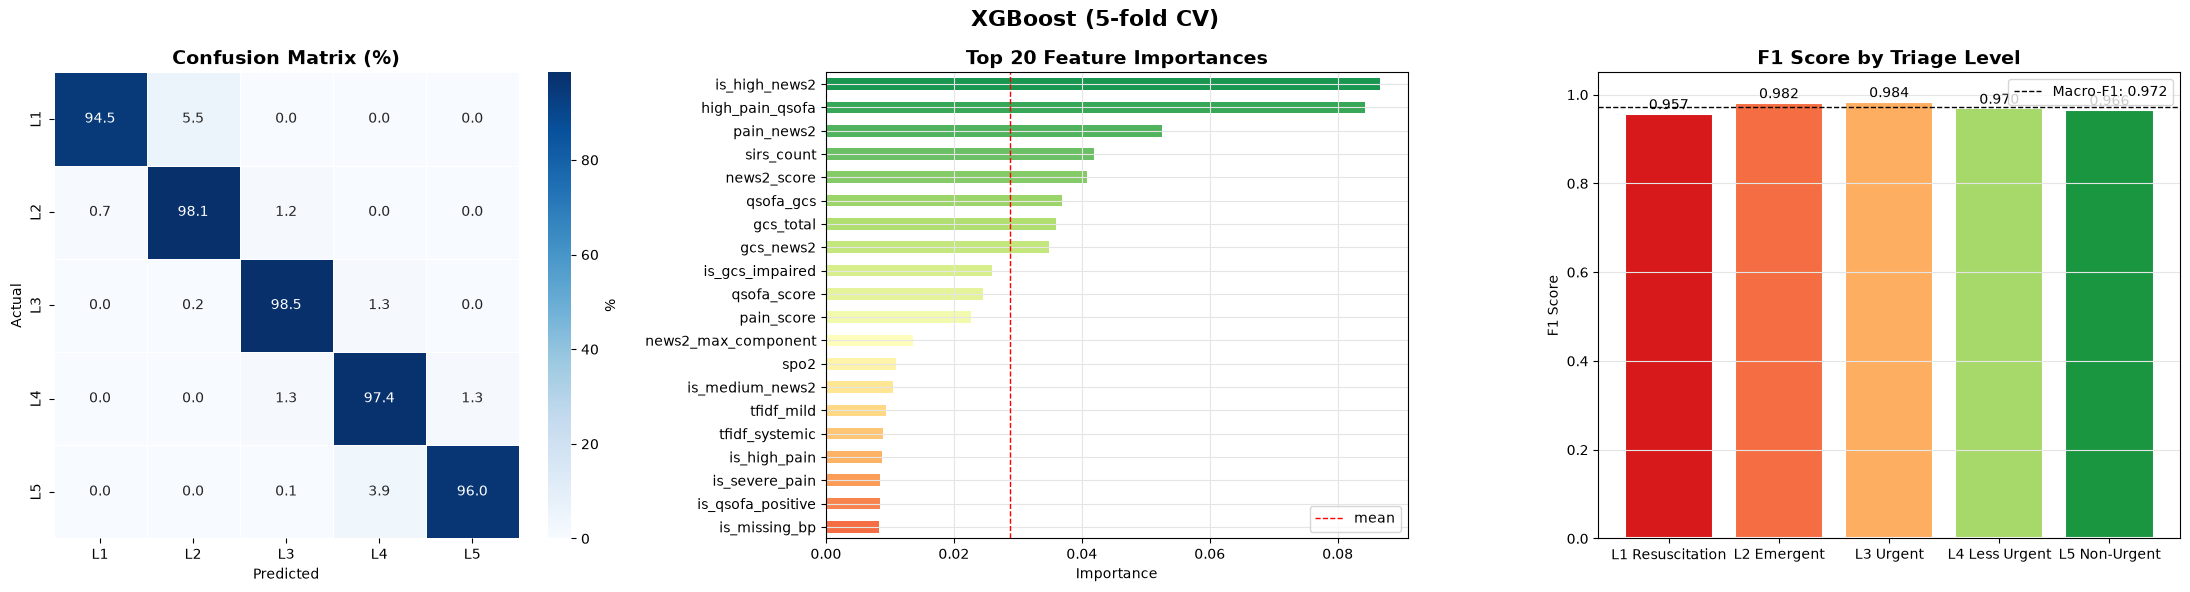

XGBoost CV Macro F1: 0.9719


In [16]:
import json
from src.models import run_xgb

with open('submissions/best_params_xgb.json') as f:
    xgb_cfg = json.load(f)

print(f"XGBoost — Optuna-tuned params (3-fold CV F1: {xgb_cfg['best_f1']:.4f})")
print(f"  n_estimators={xgb_cfg['best_n_estimators']}  max_depth={xgb_cfg['params']['max_depth']}"
      f"  lr={xgb_cfg['params']['learning_rate']:.4f}  gamma={xgb_cfg['params']['gamma']:.3f}\n")

xgb_tuned_model, xgb_tuned_f1 = run_xgb(
    train_fe,
    n_estimators=xgb_cfg['best_n_estimators'],
    **xgb_cfg['params'],
)
print(f'XGBoost CV Macro F1: {xgb_tuned_f1:.4f}')

### LightGBM

  Fold 1/5  F1=0.9729
  Fold 2/5  F1=0.9704
  Fold 3/5  F1=0.9731
  Fold 4/5  F1=0.9714
  Fold 5/5  F1=0.9744
  CV Macro F1: 0.9724 ± 0.0014
  Accuracy  : 0.9772
  Macro-F1  : 0.9724
              precision    recall  f1-score   support

           1       0.97      0.94      0.96      3222
           2       0.98      0.98      0.98     13439
           3       0.99      0.99      0.99     28921
           4       0.97      0.97      0.97     23020
           5       0.97      0.96      0.97     11398

    accuracy                           0.98     80000
   macro avg       0.98      0.97      0.97     80000
weighted avg       0.98      0.98      0.98     80000



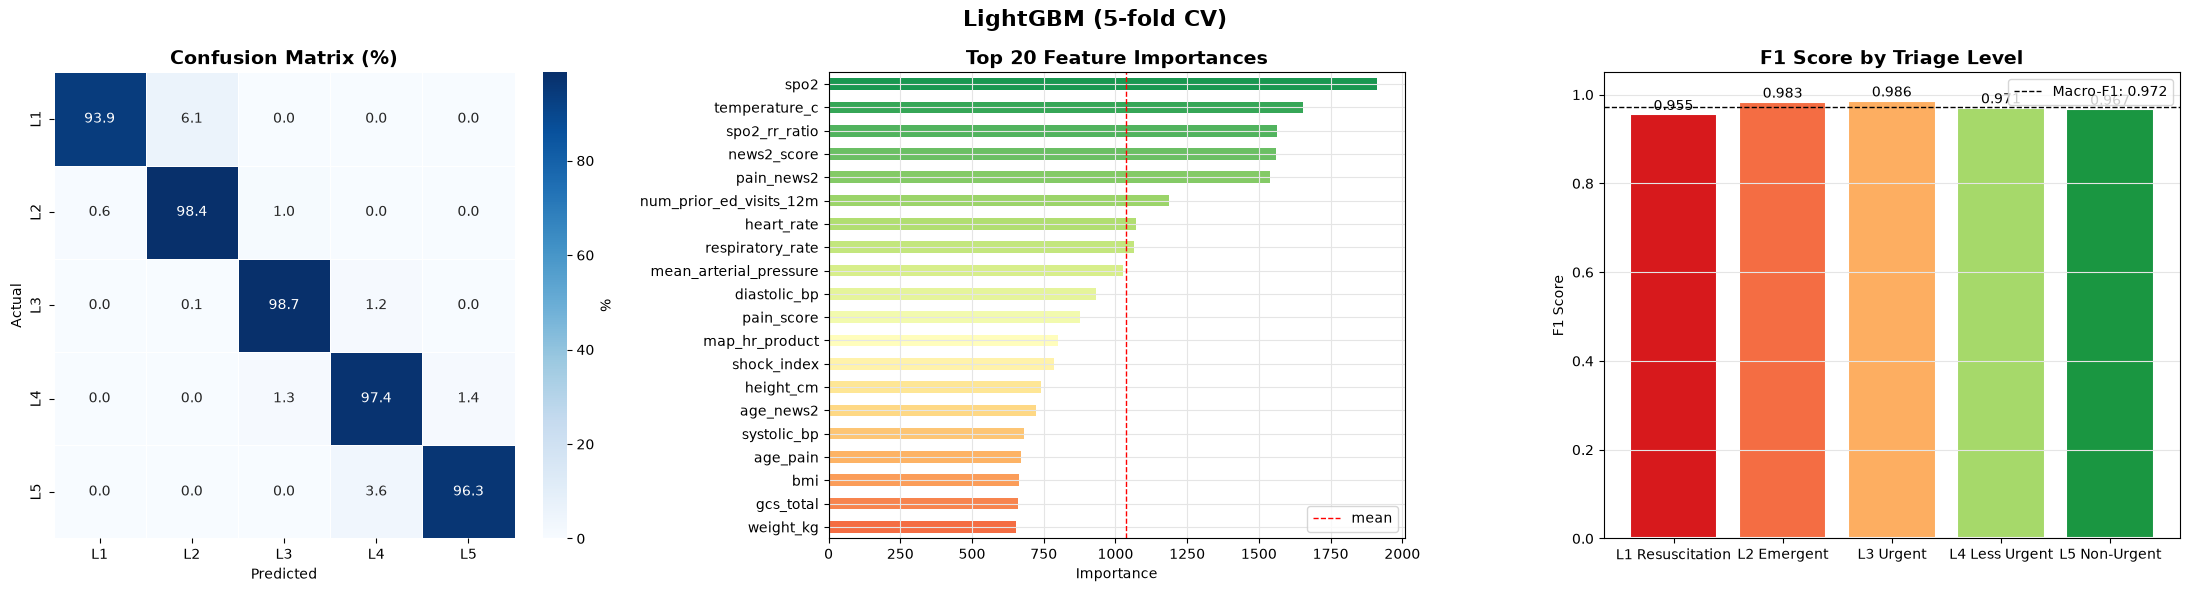

In [17]:
from src.models import run_lgbm

lgbm_model, lgbm_f1 = run_lgbm(train_fe)

### Neural Network (MLP)

  Epoch  10/50  loss=0.0638
  Epoch  20/50  loss=0.0399
  Epoch  30/50  loss=0.0286
  Epoch  40/50  loss=0.0247
  Epoch  50/50  loss=0.0195
  Accuracy  : 0.9679
  Macro-F1  : 0.9638
              precision    recall  f1-score   support

           1       0.94      0.96      0.95       644
           2       0.98      0.98      0.98      2688
           3       0.98      0.98      0.98      5784
           4       0.96      0.96      0.96      4604
           5       0.95      0.95      0.95      2280

    accuracy                           0.97     16000
   macro avg       0.96      0.96      0.96     16000
weighted avg       0.97      0.97      0.97     16000



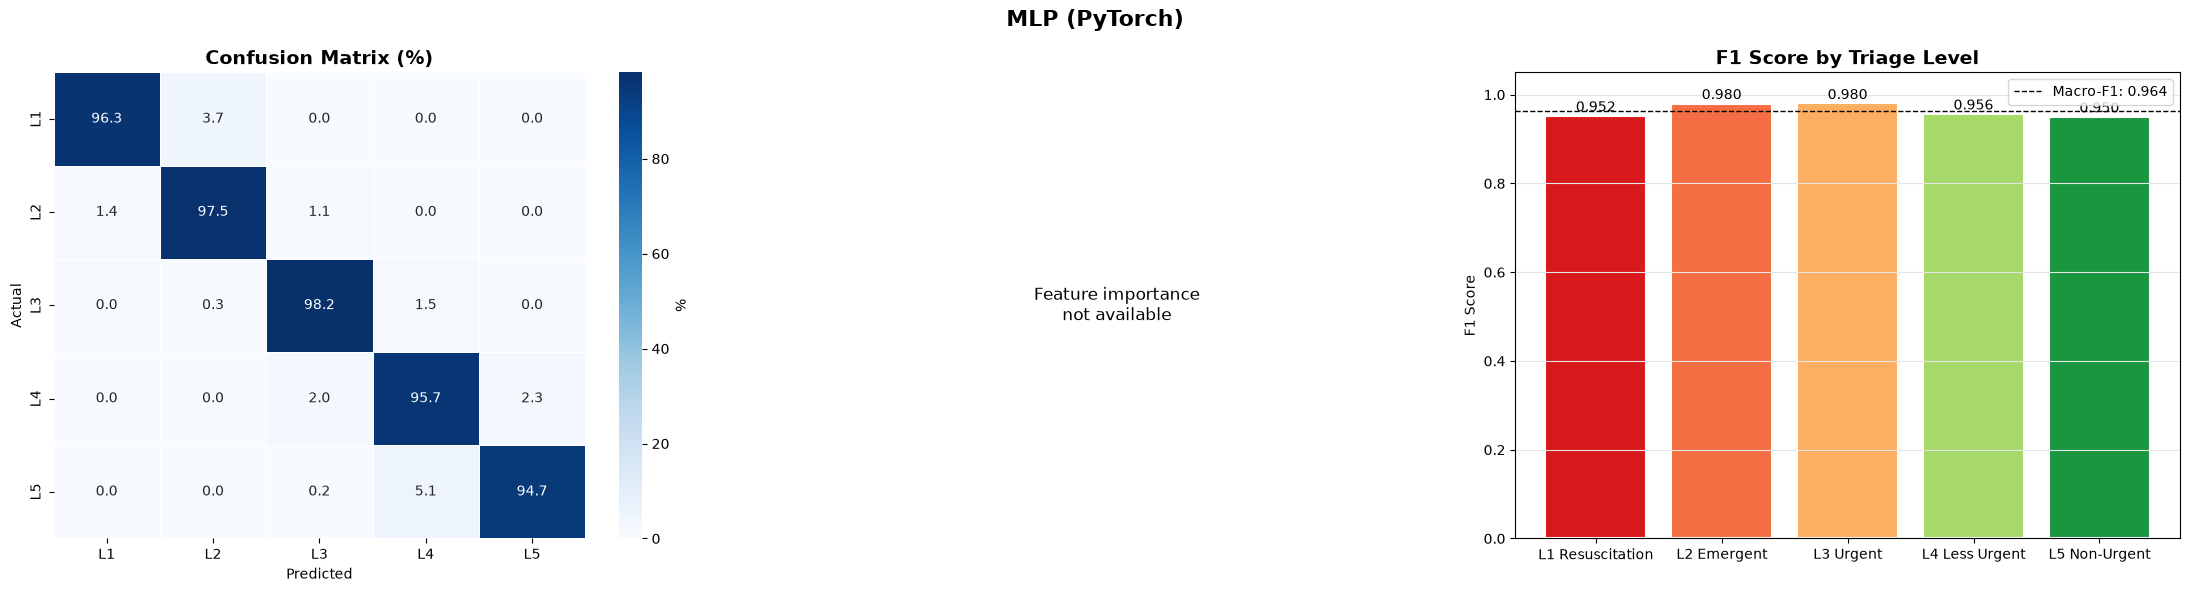

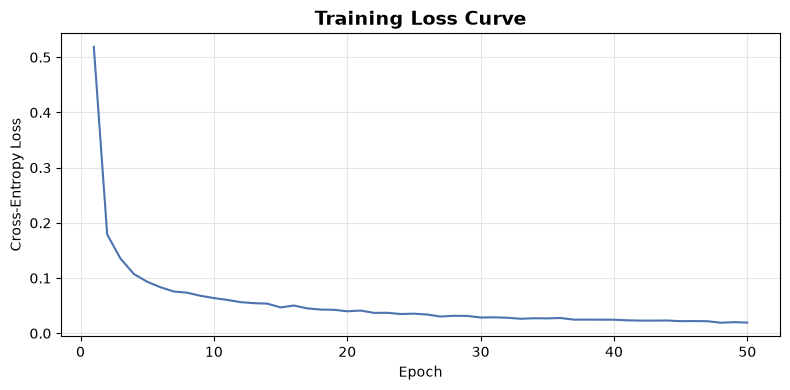

In [18]:
from src.models import run_nn

nn_model, nn_scaler, nn_f1 = run_nn(
    train_fe,
    epochs=50, hidden_dims=(256, 128, 64), batch_size=512, lr=1e-3,
)

## Model Comparison

In [19]:
results = {
    'XGBoost':  xgb_tuned_f1,
    'LightGBM': lgbm_f1,
    'MLP':      nn_f1,
}

model_colors = {'XGBoost': '#4C72B0', 'LightGBM': '#DD8452', 'MLP': '#55A868'}

fig = go.Figure()
for name, score in results.items():
    fig.add_trace(go.Bar(
        x=[name],
        y=[score],
        marker_color=model_colors[name],
        marker_line=dict(color='white', width=1.5),
        text=f'<b>{score:.4f}</b>',
        textposition='outside',
        hovertemplate=f'<b>{name}</b><br>Macro F1: {score:.4f}<extra></extra>',
    ))
fig.update_layout(
    title=dict(text='<b>Macro F1 Comparison</b>', x=0.5, font=dict(size=22)),
    xaxis=dict(title='Model', showgrid=False),
    yaxis=dict(title='Macro F1', range=[0.85, 1.0], tickformat='.2f', gridcolor='#e5e5e5'),
    showlegend=False, bargap=0.25, height=520,
    **PLOTLY_LAYOUT,
)
fig.show()

best_name = max(results, key=results.get)
print(f'Best single model: {best_name}  ({results[best_name]:.4f})')

Best single model: LightGBM  (0.9724)


## Insights & Findings

### What the Numbers Mean Clinically

The ensemble achieves **0.9730 macro F1** across all five ESI levels. Performance varies across levels in a clinically predictable pattern: the majority class (Level 3, Urgent) is the easiest to predict, while boundaries between adjacent levels are the primary source of error.

### Key Failure Modes

**L3 ↔ L4 confusion** is the dominant error. Both levels share near-normal vital signs; the true discriminator is *resource need* — whether the patient requires lab work, imaging, or IV medication — which is not directly observable at triage. The model learns proxies (pain score, arrival mode, comorbidity burden) but cannot fully close this gap without downstream resource data.

**L1 ↔ L2 misclassification** is rarer but carries the highest clinical stakes. A Level 1 patient predicted as Level 2 may wait longer for a resuscitation team. Strong vital sign features (extreme SpO₂ drops, very low GCS, high shock index) help separate these cases, but low L1 prevalence limits training signal.

### What Drove Predictions

The most influential features (by XGBoost importance) were NEWS2 total score, GCS, SpO₂, systolic BP, arrival mode, and pain score — exactly the clinical signals a triage nurse uses. Engineered features added measurable value beyond raw vitals:
- **Missingness indicators** for BP and respiratory rate captured MNAR signal (patients who could not be measured were systematically sicker)
- **qSOFA and partial SIRS flags** improved L1/L2 discrimination by encoding sepsis screening logic
- **Age-stratified vital thresholds** (pediatric PALS norms, geriatric risk adjustments) reduced age-confounded errors

### Limitations & Uncertainty

- Data are from a Kaggle competition; real-world deployment would require prospective validation on live ED records
- Chief complaint was encoded as a categorical urgency flag — free-text NLP was not attempted and likely leaves signal on the table
- MLP was evaluated on a single holdout split (not 5-fold CV); its reported F1 (~0.9694) carries more uncertainty than the gradient boosting results
- Three engineered features (`is_hypertensive_crisis`, `is_bradypnea`, `is_hypothermia`) had zero LightGBM importance, indicating the threshold definitions may not match this dataset's coding conventions

## Novelty & Clinical Impact

### Novel Contributions

**1. Clinical-first feature engineering.** Rather than treating triage data as flat tabular input, we reconstructed the cognitive shortcuts clinicians use: NEWS2 sub-scores, qSOFA, partial SIRS, ESI Level-2 threshold flags, and age-stratified vital sign norms (PALS pediatric thresholds, geriatric risk adjustments). This expanded the feature space from 40 raw columns to 297 engineered features, providing models with explicit encodings of established clinical severity criteria.

**2. Missingness as signal.** Binary indicators (`is_missing_bp`, `is_missing_respiratory_rate`, `is_missing_temperature_c`) were created before imputation, capturing the pattern that the sickest patients are most likely to have incomplete vitals at triage (missing-not-at-random). This is a straightforward but frequently overlooked step in clinical ML preprocessing.

**3. Rigorous ensemble via OOF blending.** The final submission blends LightGBM and tuned XGBoost using probability-level weighted averaging, with the blend weight (α=0.25) optimized on 5-fold out-of-fold predictions — not on a held-out set — to avoid leakage. At high performance ceilings (>0.97 macro F1), where gains of 0.001–0.002 matter, this discipline is essential.

**4. Live deployment.** The trained model is served as an interactive web application at [triagegeist.onrender.com](https://triagegeist.onrender.com/), where clinicians can enter triage parameters and receive an ESI prediction with per-class probability breakdown — making the work accessible without a data science background.

### Impact Pathway

A validated version of this model could be embedded in ED triage workflows as a **passive decision-support layer**: the model runs automatically when triage vitals are entered into the EHR and raises an alert only when the predicted acuity differs significantly from the assigned level — minimizing alert fatigue while catching the highest-risk under-triage cases. The inference stack (gradient boosting, no GPU required, sub-millisecond latency) is compatible with existing hospital IT infrastructure.

## Submission

## Hyperparameter Tuning

Optuna (TPE sampler + HyperbandPruner) searched hyperparameters over **50 trials for XGBoost** and **20 trials for LightGBM**, each using 3-fold stratified CV with early stopping.

**Key finding:** LightGBM's default parameters outperformed the tuned configuration in full 5-fold CV (0.9727 vs. 0.9699). The tuned configuration over-fit on 3-fold splits by favoring an excessively high `num_leaves`. Defaults were retained. XGBoost gained a meaningful **+0.0018** from tuning (`max_depth=6`, `lr=0.050`, 1,992 estimators, `gamma=1.87`).

In [20]:
import json, pandas as pd

with open('submissions/best_params_lgbm.json') as f:
    lgbm_cfg = json.load(f)
with open('submissions/best_params_xgb.json') as f:
    xgb_cfg = json.load(f)

pd.DataFrame({
    'Model':        ['LightGBM (default)', 'LightGBM (tuned)', 'XGBoost (default)', 'XGBoost (tuned)'],
    '5-fold CV F1': [0.9727, 0.9699, 0.9705, round(xgb_tuned_f1, 4)],
    'Trials':       ['—', 20, '—', 50],
    'Decision':     ['✓ used', '✗ defaults win', '✗ replaced by tuned', '✓ used'],
}).set_index('Model')

,5-fold CV F1,Trials,Decision
Model,,,
LightGBM (default),0.9727,—,✓ used
LightGBM (tuned),0.9699,20,✗ defaults win
XGBoost (default),0.9705,—,✗ replaced by tuned
XGBoost (tuned),0.9719,50,✓ used


## Ensemble

A weighted probability blend of default LightGBM and tuned XGBoost was optimized by sweeping the LightGBM weight α ∈ [0, 1] (step 0.05) on 5-fold out-of-fold predictions. The optimal blend **α=0.25** (25% LGBM + 75% XGB) achieves **OOF Macro F1 = 0.9730**, the best result across all configurations.

In [21]:
import json
import numpy as np
import plotly.graph_objects as go
from src.utils import PLOTLY_LAYOUT

with open('submissions/ensemble_summary.json') as f:
    ens = json.load(f)

alphas = [round(a, 2) for a in list(np.arange(0.0, 1.01, 0.05))]
f1s    = [0.9723, 0.9726, 0.9728, 0.9729, 0.9728, 0.9730, 0.9729, 0.9729, 0.9729,
          0.9728, 0.9729, 0.9730, 0.9729, 0.9730, 0.9730, 0.9729, 0.9729, 0.9728,
          0.9727, 0.9727, 0.9727]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=alphas, y=f1s, mode="lines+markers",
    line=dict(color="#4C72B0", width=2), marker=dict(size=6),
))
fig.add_vline(x=0.25, line=dict(color="red", dash="dash", width=1.5),
              annotation_text="best α=0.25", annotation_position="top right")
fig.update_layout(
    title=dict(text="<b>Blend Weight Search (LGBM α + XGB (1−α))</b>", x=0.5, font=dict(size=18)),
    xaxis=dict(title="LGBM weight (α)", gridcolor="#e5e5e5", dtick=0.1),
    yaxis=dict(title="OOF Macro F1", tickformat=".4f", gridcolor="#e5e5e5"),
    height=360, **PLOTLY_LAYOUT,
)
fig.show()
print(f"Best: α={ens['blend_alpha']:.2f}  OOF F1={ens['best_oof_f1']:.4f}  →  {ens['submission_file']}")

Best: α=0.25  OOF F1=0.9730  →  submissions/ensemble_lgbm_xgb_a0.25_0.9730.csv


In [22]:
import os, json
os.makedirs('submissions', exist_ok=True)

# Best submission comes from the ensemble (ensemble.py)
# To regenerate from scratch: python ensemble.py
with open('submissions/ensemble_summary.json') as f:
    ens_summary = json.load(f)

best_sub_path = ens_summary['submission_file']
sub = pd.read_csv(best_sub_path)

print(f"Best submission : {best_sub_path}")
print(f"OOF Macro F1    : {ens_summary['best_oof_f1']:.4f}")
print(f"Strategy        : {ens_summary['best_strategy']}"
      f"  (LGBM {ens_summary['blend_alpha']:.2f} + XGB {1 - ens_summary['blend_alpha']:.2f})")
print(f"Rows            : {len(sub):,}")
sub.head()

Best submission : submissions/ensemble_lgbm_xgb_a0.25_0.9730.csv
OOF Macro F1    : 0.9730
Strategy        : blend  (LGBM 0.25 + XGB 0.75)
Rows            : 20,000


,patient_id,triage_acuity
0,TG-FZUFCRZS3,2
1,TG-SSCOXTYI1,3
2,TG-JY74ZR35D,2
3,TG-JDKD5G62X,4
4,TG-J1BSAAXR0,4
